In [3]:
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
def make_phantom(shape, d, P):
    '''Utility function to construct a phantom out of a grid of 
    mega-voxels with shape `shape`. Each mega-voxel is a cube of 
    size `d`^3, and `P` is the period of the sinusoids used to 
    construct the fiber bundles.
    '''
    nx, ny, nz = shape

    x, y, z = np.meshgrid(np.linspace(-nx/2, nx/2, nx),
                          np.linspace(-ny/2, ny/2, ny),
                          np.linspace(-nz/2, nz/2, nz),
                          indexing='ij')

    ks = np.zeros((nx//d, ny//d, 2, 3))
    ks[0, 0] = np.array([[0, 1, 0], [0, 0, 1]])  # x
    ks[1, 0] = np.array([[1, 0, 0], [0, 0, 1]])  # y
    ks[2, 0] = np.array([[1, 0, 0], [0, 1, 0]])  # z

    ks[0, 1] = np.array([[1/np.sqrt(2), 1/np.sqrt(2), 0], [0, 0, 1]])  # xy
    ks[1, 1] = np.array([[1/np.sqrt(2), 0, 1/np.sqrt(2)], [0, 1, 0]])  # xz
    ks[2, 1] = np.array([[0, 1/np.sqrt(2), 1/np.sqrt(2)], [1, 0, 0]])  # z

    phantom = np.zeros_like(x)
    for xx in range(nx//d):
        for yy in range(ny//d):
            k1, k2 = ks[xx, yy]
            wave = np.cos((2 * np.pi / P) * (k1[0] * x + k1[1] * y + k1[2] * z)) + np.cos(
                (2 * np.pi / P) * (k2[0] * x + k2[1] * y + k2[2] * z))
            sli = (slice(xx * d, (xx + 1) * d), slice(yy * d, (yy + 1) * d))
            phantom[sli] = wave[sli]

    return phantom

def plot_image(img,**kwargs):
    '''Utility function to plot 2D image'''
    fig, ax = plt.subplots(figsize=(12,8))
    ax.imshow(img, interpolation='none',**kwargs)
    ax.axis('off')
    ax.set_aspect('equal')
    return fig, ax

phantom.shape = (195, 130, 65)


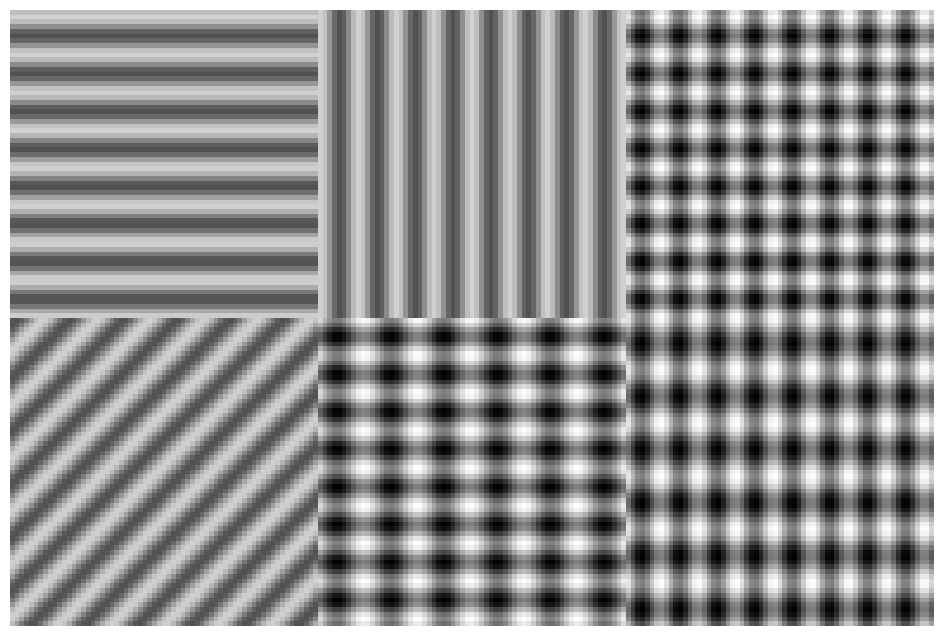

In [5]:
d = 65
shape = (d*3,d*2,d*1)
P = 8  
phantom = make_phantom(shape, d, P=P)
print(f'phantom.shape = {phantom.shape}')
plot_image(phantom[...,10].T,cmap='gray');

In [6]:
from fiberorient import StructureTensor

st = StructureTensor(d_sigma=1,n_sigma=3,verbose=True)
st.fit(phantom);

Computing gradient
Imz
Imy
Imx
Forming ST elements:
Szz
Szy
Szx
Syy
Syx
Sxx
Calculating eigenvectors/values
Done!


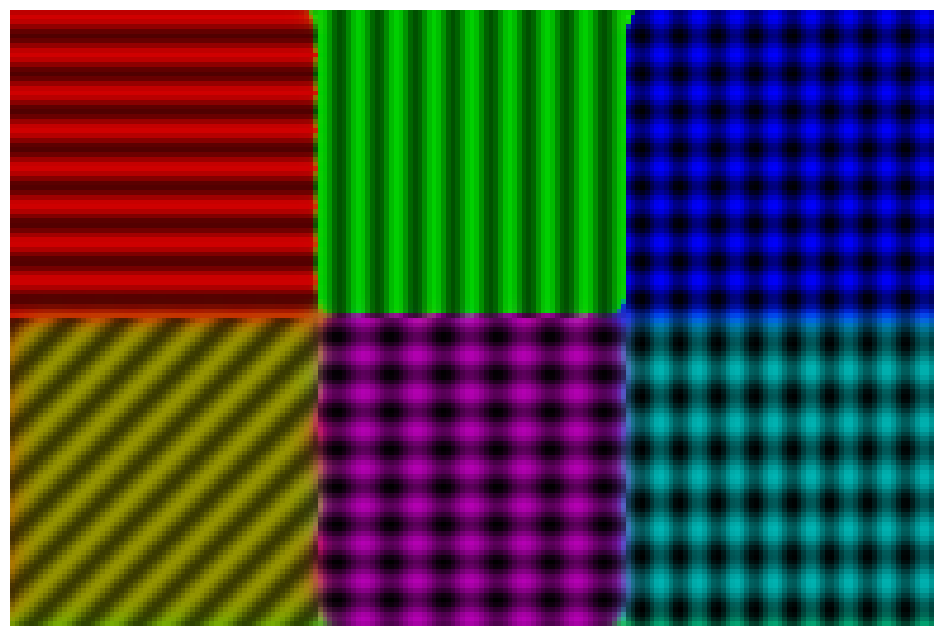

In [9]:
from fiberorient.vis import img_to_dec

vectors = st.vectors
vectors.shape
dec = img_to_dec(phantom, vectors)
img = np.swapaxes(dec[...,10,:],0,1)
plot_image(img);

/tmp/ipykernel_14018/2235802436.py:18: UserWarning: We'll no longer accept the way you call the peak_slicer function in future versions of FURY.

Here's how to call the Function peak_slicer: peak_slicer(peaks_dirs_value, peaks_values='value', mask='value', affine='value', colors='value', opacity='value', linewidth='value', lod='value', lod_points='value', lod_points_size='value', symmetric='value')

  show_vectors_2D(img,
/tmp/ipykernel_14018/2235802436.py:18: UserWarning: We'll no longer accept the way you call the display function in future versions of FURY.

Here's how to call the Function display: display(self_value, x='value', y='value', z='value')

  show_vectors_2D(img,
/tmp/ipykernel_14018/2235802436.py:18: UserWarning: We'll no longer accept the way you call the record function in future versions of FURY.

Here's how to call the Function record: record(scene='value', cam_pos='value', cam_focal='value', cam_view='value', out_path='value', path_numbering='value', n_frames='value

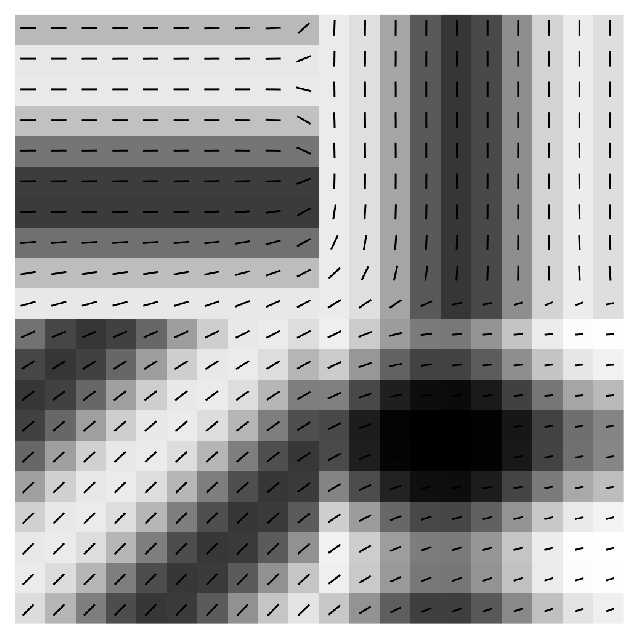

In [11]:
from fiberorient.vis import show_vectors_2D

# Works better on small arrays, demonstrating on a sub-image
# at the boundary of 4 mega-voxels

dx = 20
dy = 20

x0=d-dx//2
xf = d + dx//2
y0 = d-dy//2
yf = d+dy//2

img = phantom[x0:xf,y0:yf,10]
vecs = vectors[x0:xf,y0:yf,10,:]
out_path='st_demo.png'

show_vectors_2D(img,
                vecs,
                out_path=out_path,
                linewidth=3)
im = plt.imread(out_path)
plot_image(im,origin='lower');

In [13]:
import numpy as np
from fiberorient.odf import ODF

odf = ODF(degree=8,method='precompute').fit(vectors)

odf.coef

array([ 0.28209479,  0.00916375,  0.09777133,  0.08637386,  0.00269025,
       -0.09230594,  0.19179254,  0.03917618,  0.04680255, -0.0032332 ,
        0.07771493,  0.06369389, -0.07444074,  0.15033954, -0.00867236,
       -0.05005765, -0.05626777, -0.07289076,  0.0019394 , -0.0698786 ,
        0.09129854, -0.09708572,  0.0863615 , -0.00683508,  0.04057872,
        0.03842554, -0.01296554,  0.09757545,  0.43433293, -0.03121782,
       -0.01883493, -0.00871574,  0.07646556, -0.00260226,  0.00343378,
        0.24724025, -0.01148508,  0.10062754,  0.08929106,  0.00287579,
       -0.08213418,  0.02770035, -0.0223207 ,  0.35003853,  0.01442522])

In [14]:
from fiberorient.util import make_sphere

sphere = make_sphere(6500)
odf_on_sphere = odf.to_sphere(sphere)
print(f'odf_on_sphere.shape = {odf_on_sphere.shape}')

odf_on_sphere.shape = (6500,)


/tmp/ipykernel_14018/849268063.py:11: UserWarning: We'll no longer accept the way you call the record function in future versions of FURY.

Here's how to call the Function record: record(scene='value', cam_pos='value', cam_focal='value', cam_view='value', out_path='value', path_numbering='value', n_frames='value', az_ang='value', magnification='value', size='value', reset_camera='value', screen_clip='value', stereo='value', verbose='value')

  show_odf(odf_on_sphere,sphere,out_path='odf_on_sphere.png')


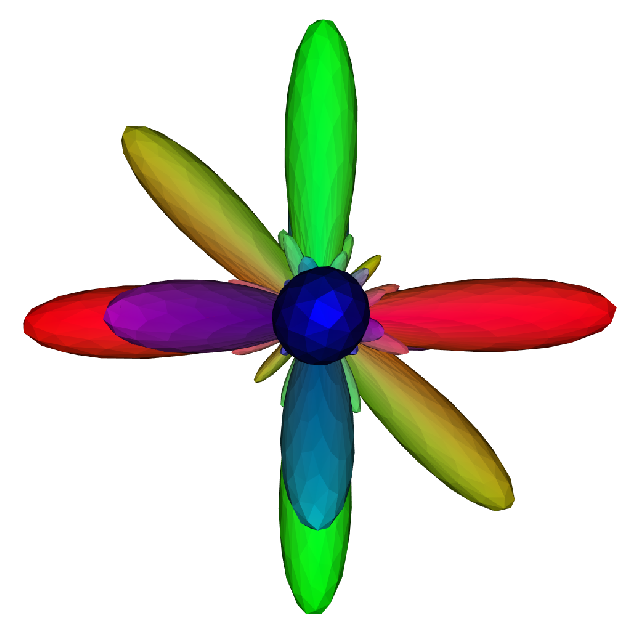

In [15]:
from fiberorient.vis import show_odf

def plot_image(img,**kwargs):
    '''Utility function to plot 2D image'''
    fig, ax = plt.subplots(figsize=(12,8))
    ax.imshow(img, interpolation='none',**kwargs)
    ax.axis('off')
    ax.set_aspect('equal')
    return fig, ax

show_odf(odf_on_sphere,sphere,out_path='odf_on_sphere.png')
im = plt.imread('odf_on_sphere.png')
plot_image(im);